In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.10.0+cu128
True
Tesla T4


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("使用设备:", device)

使用设备: cuda


In [3]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1) / (d_k ** 0.5)

    if mask is not None:
        scores = scores + mask  # mask里是-1e9，softmax后趋近于0

    weights = F.softmax(scores, dim=-1)
    output = weights @ V
    return output, weights

In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=512, h=8):
        super().__init__()
        self.h = h
        self.d_k = d_model // h

        # 四个线性变换矩阵，对应论文里的WQ WK WV WO
        self.WQ = nn.Linear(d_model, d_model)
        self.WK = nn.Linear(d_model, d_model)
        self.WV = nn.Linear(d_model, d_model)
        self.WO = nn.Linear(d_model, d_model)

    def forward(self, Q, K, V, mask=None):
        batch_size = Q.shape[0]

        # 线性变换 + 切成h个头
        # (batch, seq_len, d_model) -> (batch, h, seq_len, d_k)
        Q = self.WQ(Q).view(batch_size, -1, self.h, self.d_k).transpose(1, 2)
        K = self.WK(K).view(batch_size, -1, self.h, self.d_k).transpose(1, 2)
        V = self.WV(V).view(batch_size, -1, self.h, self.d_k).transpose(1, 2)

        # 每个头独立做attention
        output, weights = scaled_dot_product_attention(Q, K, V, mask)

        # 拼接所有头 + 最终线性变换
        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.h * self.d_k)
        output = self.WO(output)

        return output, weights

# 测试
mha = MultiHeadAttention().to(device)
x = torch.randn(2, 3, 512).to(device)  # batch=2, seq_len=3, d_model=512
output, weights = mha(x, x, x)
print("输出shape:", output.shape)   # 应该是 (2, 3, 512)
print("权重shape:", weights.shape)  # 应该是 (2, 8, 3, 3)

输出shape: torch.Size([2, 3, 512])
权重shape: torch.Size([2, 8, 3, 3])


In [5]:
class FeedForward(nn.Module):
    def __init__(self, d_model=512, d_ff=2048):
        super().__init__()
        self.W1 = nn.Linear(d_model, d_ff)
        self.W2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.W2(F.relu(self.W1(x)))


class EncoderLayer(nn.Module):
    def __init__(self, d_model=512, h=8, d_ff=2048, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, h)
        self.ff = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_output, weights = self.attention(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.ff(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x, weights


class DecoderLayer(nn.Module):
    def __init__(self, d_model=512, h=8, d_ff=2048, dropout=0.1):
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, h)
        self.cross_attention = MultiHeadAttention(d_model, h)
        self.ff = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        # 第一个子层：masked self-attention
        attn_output, _ = self.self_attention(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))

        # 第二个子层：cross attention，Q来自decoder，K/V来自encoder
        attn_output, weights = self.cross_attention(x, encoder_output, encoder_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))

        # 第三个子层：feed forward
        ff_output = self.ff(x)
        x = self.norm3(x + self.dropout(ff_output))
        return x, weights


def positional_encoding(seq_len, d_model, device):
    PE = torch.zeros(seq_len, d_model).to(device)
    position = torch.arange(0, seq_len).unsqueeze(1).float()
    div_term = torch.pow(10000, torch.arange(0, d_model, 2).float() / d_model)
    PE[:, 0::2] = torch.sin(position / div_term)
    PE[:, 1::2] = torch.cos(position / div_term)
    return PE.unsqueeze(0)  # (1, seq_len, d_model)


# 测试
enc_layer = EncoderLayer().to(device)
dec_layer = DecoderLayer().to(device)

src = torch.randn(2, 5, 512).to(device)  # 源序列
tgt = torch.randn(2, 3, 512).to(device)  # 目标序列

enc_output, _ = enc_layer(src)
dec_output, _ = dec_layer(tgt, enc_output)

print("Encoder输出:", enc_output.shape)  # (2, 5, 512)
print("Decoder输出:", dec_output.shape)  # (2, 3, 512)

Encoder输出: torch.Size([2, 5, 512])
Decoder输出: torch.Size([2, 3, 512])


In [6]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size,
                 d_model=256, h=8, N=3, d_ff=512, dropout=0.1):
        super().__init__()
        # Embedding层：把token id变成向量
        self.src_embedding = nn.Embedding(src_vocab_size, d_model)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model)
        self.d_model = d_model

        # N个Encoder层和Decoder层
        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, h, d_ff, dropout) for _ in range(N)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, h, d_ff, dropout) for _ in range(N)])

        # 最终输出层：把向量变成词表概率
        self.output_layer = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def encode(self, src, src_mask=None):
        x = self.src_embedding(src) * (self.d_model ** 0.5)
        x = x + positional_encoding(src.shape[1], self.d_model, src.device)
        x = self.dropout(x)
        for layer in self.encoder_layers:
            x, _ = layer(x, src_mask)
        return x

    def decode(self, tgt, encoder_output, src_mask=None, tgt_mask=None):
        x = self.tgt_embedding(tgt) * (self.d_model ** 0.5)
        x = x + positional_encoding(tgt.shape[1], self.d_model, tgt.device)
        x = self.dropout(x)
        for layer in self.decoder_layers:
            x, _ = layer(x, encoder_output, src_mask, tgt_mask)
        return x

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        encoder_output = self.encode(src, src_mask)
        decoder_output = self.decode(tgt, encoder_output, src_mask, tgt_mask)
        return self.output_layer(decoder_output)

    def make_tgt_mask(self, tgt):
        seq_len = tgt.shape[1]
        # 上三角mask，防止decoder看到未来的词
        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
        mask = mask.float().masked_fill(mask, float('-inf')).to(tgt.device)
        return mask

# 注意：模型缩小了，d_model=256, N=3，适合在Colab上训练
model = Transformer(src_vocab_size=1000, tgt_vocab_size=1000).to(device)

# 统计参数量
total_params = sum(p.numel() for p in model.parameters())
print(f"模型参数量: {total_params:,}")

# 测试forward
src = torch.randint(0, 1000, (2, 5)).to(device)
tgt = torch.randint(0, 1000, (2, 3)).to(device)
tgt_mask = model.make_tgt_mask(tgt)
output = model(src, tgt, tgt_mask=tgt_mask)
print(f"输出shape: {output.shape}")  # (2, 3, 1000)

模型参数量: 4,722,664
输出shape: torch.Size([2, 3, 1000])


In [8]:
# 下载数据集
!wget https://www.manythings.org/anki/cmn-eng.zip
!unzip cmn-eng.zip

import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import jieba

# 读取数据
pairs = []
with open('cmn.txt', 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            eng, chn = parts[0], parts[1]
            pairs.append((eng, chn))

print(f"总句对数: {len(pairs)}")
print("前5条:")
for eng, chn in pairs[:5]:
    print(f"  {eng} → {chn}")

--2026-05-04 07:45:44--  https://www.manythings.org/anki/cmn-eng.zip
Resolving www.manythings.org (www.manythings.org)... 173.254.30.110
Connecting to www.manythings.org (www.manythings.org)|173.254.30.110|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1386340 (1.3M) [application/zip]
Saving to: ‘cmn-eng.zip.1’

cmn-eng.zip.1       100%[===================>]   1.32M  6.32MB/s    in 0.2s    

2026-05-04 07:45:45 (6.32 MB/s) - ‘cmn-eng.zip.1’ saved [1386340/1386340]

Archive:  cmn-eng.zip
replace cmn.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: cmn.txt                 
replace _about.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: _about.txt              


/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")


总句对数: 32028
前5条:
  Hi. → 嗨。
  Hi. → 你好。
  Run. → 你用跑的。
  Who? → 誰？
  Fire! → 火！


In [9]:
# 特殊token
PAD, BOS, EOS, UNK = 0, 1, 2, 3

def build_vocab(sentences, min_freq=2):
    counter = Counter()
    for sent in sentences:
        counter.update(sent)
    vocab = {'<pad>': PAD, '<bos>': BOS, '<eos>': EOS, '<unk>': UNK}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

def tokenize_en(text):
    return text.lower().split()

def tokenize_zh(text):
    return list(jieba.cut(text))

# 构建词表
eng_tokens = [tokenize_en(eng) for eng, _ in pairs]
chn_tokens = [tokenize_zh(chn) for _, chn in pairs]

eng_vocab = build_vocab(eng_tokens)
chn_vocab = build_vocab(chn_tokens)

print(f"英文词表大小: {len(eng_vocab)}")
print(f"中文词表大小: {len(chn_vocab)}")

# Dataset
class TranslationDataset(Dataset):
    def __init__(self, pairs, eng_vocab, chn_vocab, max_len=30):
        self.data = []
        for (eng, chn), eng_tok, chn_tok in zip(pairs, eng_tokens, chn_tokens):
            # 过滤太长的句子
            if len(eng_tok) > max_len or len(chn_tok) > max_len:
                continue
            src = [eng_vocab.get(t, UNK) for t in eng_tok]
            tgt = [chn_vocab.get(t, UNK) for t in chn_tok]
            self.data.append((src, tgt))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    # padding到同一长度
    src_len = max(len(s) for s in src_batch)
    tgt_len = max(len(t) for t in tgt_batch)

    src_padded = torch.tensor([s + [PAD] * (src_len - len(s)) for s in src_batch])
    # tgt输入：BOS + 序列，tgt输出：序列 + EOS
    tgt_in  = torch.tensor([[BOS] + t + [PAD] * (tgt_len - len(t)) for t in tgt_batch])
    tgt_out = torch.tensor([t + [EOS] + [PAD] * (tgt_len - len(t)) for t in tgt_batch])

    return src_padded, tgt_in, tgt_out

dataset = TranslationDataset(pairs, eng_vocab, chn_vocab)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)

print(f"有效句对数: {len(dataset)}")
print(f"每个epoch的batch数: {len(dataloader)}")

# 看一个batch
src, tgt_in, tgt_out = next(iter(dataloader))
print(f"src shape: {src.shape}")
print(f"tgt_in shape: {tgt_in.shape}")
print(f"tgt_out shape: {tgt_out.shape}")

Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 0.617 seconds.
DEBUG:jieba:Loading model cost 0.617 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


英文词表大小: 6973
中文词表大小: 8200
有效句对数: 32026
每个epoch的batch数: 501
src shape: torch.Size([64, 12])
tgt_in shape: torch.Size([64, 16])
tgt_out shape: torch.Size([64, 16])


模型参数量: 9,945,352
Epoch 1/10  Loss: 5.0487
Epoch 2/10  Loss: 4.2490
Epoch 3/10  Loss: 3.9345
Epoch 4/10  Loss: 3.6908
Epoch 5/10  Loss: 3.4944
Epoch 6/10  Loss: 3.3254
Epoch 7/10  Loss: 3.1708
Epoch 8/10  Loss: 3.0306
Epoch 9/10  Loss: 2.8991
Epoch 10/10  Loss: 2.7785


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


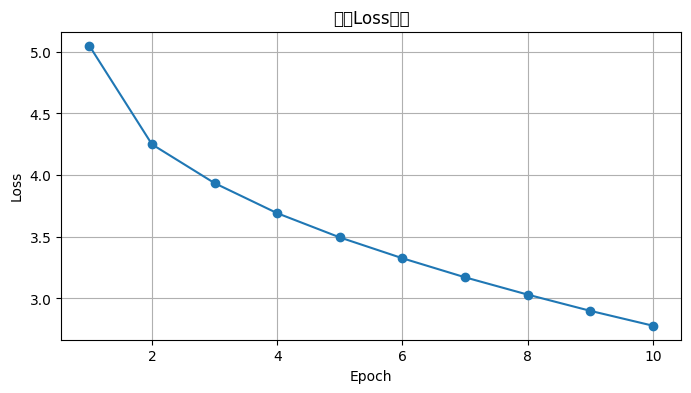

In [10]:
# 用真实词表大小初始化模型
model = Transformer(
    src_vocab_size=len(eng_vocab),
    tgt_vocab_size=len(chn_vocab),
    d_model=256,
    h=8,
    N=3,
    d_ff=512,
    dropout=0.1
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"模型参数量: {total_params:,}")

# 忽略padding位置的loss
criterion = nn.CrossEntropyLoss(ignore_index=PAD)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98))

def train_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0
    for src, tgt_in, tgt_out in dataloader:
        src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)

        tgt_mask = model.make_tgt_mask(tgt_in)
        output = model(src, tgt_in, tgt_mask=tgt_mask)

        # output: (batch, seq_len, vocab_size) -> (batch*seq_len, vocab_size)
        loss = criterion(output.view(-1, len(chn_vocab)), tgt_out.view(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

# 训练10个epoch，看loss能不能下降
losses = []
for epoch in range(10):
    loss = train_epoch(model, dataloader, optimizer, criterion)
    losses.append(loss)
    print(f"Epoch {epoch+1}/10  Loss: {loss:.4f}")

# 画loss曲线
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('训练Loss曲线')
plt.grid(True)
plt.show()

In [11]:
# 继续训练20个epoch
for epoch in range(20):
    loss = train_epoch(model, dataloader, optimizer, criterion)
    losses.append(loss)
    print(f"Epoch {epoch+11}/30  Loss: {loss:.4f}")

# 推理函数
def translate(sentence, model, eng_vocab, chn_vocab, max_len=50):
    model.eval()

    # 构建反向词表（id -> 词）
    chn_idx2word = {v: k for k, v in chn_vocab.items()}

    # tokenize + 转id
    tokens = tokenize_en(sentence)
    src = torch.tensor([[eng_vocab.get(t, UNK) for t in tokens]]).to(device)

    # encoder
    with torch.no_grad():
        encoder_output = model.encode(src)

        # 逐词生成
        tgt = torch.tensor([[BOS]]).to(device)
        result = []

        for _ in range(max_len):
            tgt_mask = model.make_tgt_mask(tgt)
            output = model.decode(tgt, encoder_output, tgt_mask=tgt_mask)
            logits = model.output_layer(output[:, -1, :])
            next_token = logits.argmax(-1).item()

            if next_token == EOS:
                break
            result.append(chn_idx2word.get(next_token, '<unk>'))
            tgt = torch.cat([tgt, torch.tensor([[next_token]]).to(device)], dim=1)

    return ''.join(result)

# 测试几个句子
test_sentences = [
    "I love you.",
    "Hello.",
    "She is a student.",
    "I am hungry.",
    "Thank you."
]

print("翻译结果：")
for sent in test_sentences:
    result = translate(sent, model, eng_vocab, chn_vocab)
    print(f"  {sent} → {result}")

Epoch 11/30  Loss: 2.6624
Epoch 12/30  Loss: 2.5531
Epoch 13/30  Loss: 2.4541
Epoch 14/30  Loss: 2.3547
Epoch 15/30  Loss: 2.2627
Epoch 16/30  Loss: 2.1734
Epoch 17/30  Loss: 2.0895
Epoch 18/30  Loss: 2.0066
Epoch 19/30  Loss: 1.9286
Epoch 20/30  Loss: 1.8548
Epoch 21/30  Loss: 1.7844
Epoch 22/30  Loss: 1.7143
Epoch 23/30  Loss: 1.6452
Epoch 24/30  Loss: 1.5871
Epoch 25/30  Loss: 1.5255
Epoch 26/30  Loss: 1.4649
Epoch 27/30  Loss: 1.4124
Epoch 28/30  Loss: 1.3591
Epoch 29/30  Loss: 1.3030
Epoch 30/30  Loss: 1.2557
翻译结果：
  I love you. → 我爱你。我愛你。
  Hello. → <unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk>
  She is a student. → 她是个大学生。她是學生。
  I am hungry. → 我饿了，但我饿很饿。
  Thank you. → 谢谢你打谢谢，谢谢。


In [13]:
def translate(sentence, model, eng_vocab, chn_vocab, max_len=50):
    model.eval()
    chn_idx2word = {v: k for k, v in chn_vocab.items()}
    tokens = tokenize_en(sentence)
    src = torch.tensor([[eng_vocab.get(t, UNK) for t in tokens]]).to(device)

    with torch.no_grad():
        encoder_output = model.encode(src)
        tgt = torch.tensor([[BOS]]).to(device)
        result = []

        for _ in range(max_len):
            tgt_mask = model.make_tgt_mask(tgt)
            output = model.decode(tgt, encoder_output, tgt_mask=tgt_mask)
            logits = model.output_layer(output[:, -1, :])

            # 惩罚已经出现过的token，减少重复
            for token_id in set(tgt[0].tolist()):
                logits[0, token_id] /= 1.5

            next_token = logits.argmax(-1).item()
            if next_token == EOS or next_token == PAD:
                break
            result.append(chn_idx2word.get(next_token, ''))
            tgt = torch.cat([tgt, torch.tensor([[next_token]]).to(device)], dim=1)

    return ''.join(result)

# 继续训练
for epoch in range(20):
    loss = train_epoch(model, dataloader, optimizer, criterion)
    losses.append(loss)
    print(f"Epoch {epoch+31}/50  Loss: {loss:.4f}")

# 再测试
print("翻译结果：")
for sent in test_sentences:
    result = translate(sent, model, eng_vocab, chn_vocab)
    print(f"  {sent} → {result}")

Epoch 31/50  Loss: 1.0893
Epoch 32/50  Loss: 1.0496
Epoch 33/50  Loss: 1.0078
Epoch 34/50  Loss: 0.9707
Epoch 35/50  Loss: 0.9321
Epoch 36/50  Loss: 0.9016
Epoch 37/50  Loss: 0.8682
Epoch 38/50  Loss: 0.8335
Epoch 39/50  Loss: 0.8057
Epoch 40/50  Loss: 0.7791
Epoch 41/50  Loss: 0.7504
Epoch 42/50  Loss: 0.7234
Epoch 43/50  Loss: 0.6970
Epoch 44/50  Loss: 0.6727
Epoch 45/50  Loss: 0.6515
Epoch 46/50  Loss: 0.6263
Epoch 47/50  Loss: 0.6084
Epoch 48/50  Loss: 0.5877
Epoch 49/50  Loss: 0.5689
Epoch 50/50  Loss: 0.5509
翻译结果：
  I love you. → 我喜欢你。
  Hello. → <unk>讓<unk><unk><unk>“ <unk>、<unk>” <unk><unk>。
  She is a student. → 她是个大学生。
  I am hungry. → 我饿了，但我肚子饿极了。
  Thank you. → 谢谢你，謝謝好起来的话。


In [14]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

def tokenize_en(text):
    return nltk.word_tokenize(text.lower())

# 重新处理数据，同时做简繁体去重（只保留每句英文的第一条翻译）
seen_eng = set()
pairs_dedup = []
for eng, chn in pairs:
    if eng not in seen_eng:
        seen_eng.add(eng)
        pairs_dedup.append((eng, chn))

print(f"去重前: {len(pairs)} 条")
print(f"去重后: {len(pairs_dedup)} 条")

# 重新tokenize
eng_tokens = [tokenize_en(eng) for eng, _ in pairs_dedup]
chn_tokens = [tokenize_zh(chn) for _, chn in pairs_dedup]

# 重建词表
eng_vocab = build_vocab(eng_tokens)
chn_vocab = build_vocab(chn_tokens)
print(f"英文词表: {len(eng_vocab)}")
print(f"中文词表: {len(chn_vocab)}")

# 重建dataset
dataset = TranslationDataset(pairs_dedup, eng_vocab, chn_vocab)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
print(f"有效句对: {len(dataset)}")

# 重新初始化模型，加大dropout
model = Transformer(
    src_vocab_size=len(eng_vocab),
    tgt_vocab_size=len(chn_vocab),
    d_model=256, h=8, N=3, d_ff=512,
    dropout=0.2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98))

# 从头训练50个epoch
losses = []
for epoch in range(50):
    loss = train_epoch(model, dataloader, optimizer, criterion)
    losses.append(loss)
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/50  Loss: {loss:.4f}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


去重前: 32028 条
去重后: 30193 条
英文词表: 4567
中文词表: 7947
有效句对: 30189
Epoch 5/50  Loss: 3.6306
Epoch 10/50  Loss: 2.9783
Epoch 15/50  Loss: 2.5299
Epoch 20/50  Loss: 2.1791
Epoch 25/50  Loss: 1.8954
Epoch 30/50  Loss: 1.6608
Epoch 35/50  Loss: 1.4667
Epoch 40/50  Loss: 1.3009
Epoch 45/50  Loss: 1.1591
Epoch 50/50  Loss: 1.0380


In [15]:
test_sentences = [
    "I love you.",
    "Hello.",
    "She is a student.",
    "I am hungry.",
    "Thank you.",
    "Where are you going?",
    "I don't know.",
    "It's a beautiful day.",
]

print("翻译结果：")
for sent in test_sentences:
    result = translate(sent, model, eng_vocab, chn_vocab)
    print(f"  {sent} → {result}")

翻译结果：
  I love you. → 我愛你。
  Hello. → 你好。<unk>！我看起來。
  She is a student. → 她是學生。她是学生
  I am hungry. → 我餓了。<unk>饿。我很肚子饿极了。
  Thank you. → 谢谢你。謝謝我了！
  Where are you going? → 你去哪裡?
  I don't know. → 我不知道。
  It's a beautiful day. → 天氣<unk>漂亮。是美丽的一天啊


In [16]:
!pip install opencc-python-reimplemented

import opencc
converter = opencc.OpenCC('t2s')  # 繁体转简体

# 重新处理数据，繁体转简体
pairs_simplified = []
for eng, chn in pairs_dedup:
    chn_simplified = converter.convert(chn)
    pairs_simplified.append((eng, chn_simplified))

# 看一下效果
print("转换效果：")
for i in [0, 1, 5, 10, 20]:
    orig = pairs_dedup[i][1]
    simp = pairs_simplified[i][1]
    if orig != simp:
        print(f"  {orig} → {simp}")
    else:
        print(f"  {simp} (无变化)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.8/481.8 kB 11.6 MB/s eta 0:00:00
转换效果：
  嗨。 (无变化)
  你用跑的。 (无变化)
  住手！ (无变化)
  我试试。 (无变化)
  我沒事。 → 我没事。


In [17]:
# 重新tokenize
eng_tokens = [tokenize_en(eng) for eng, _ in pairs_simplified]
chn_tokens = [tokenize_zh(chn) for _, chn in pairs_simplified]

# 重建词表
eng_vocab = build_vocab(eng_tokens)
chn_vocab = build_vocab(chn_tokens)
print(f"英文词表: {len(eng_vocab)}")
print(f"中文词表: {len(chn_vocab)}")

# 重建dataset
dataset = TranslationDataset(pairs_simplified, eng_vocab, chn_vocab)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
print(f"有效句对: {len(dataset)}")

# 重新初始化模型
model = Transformer(
    src_vocab_size=len(eng_vocab),
    tgt_vocab_size=len(chn_vocab),
    d_model=256, h=8, N=3, d_ff=512,
    dropout=0.2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98))
criterion = nn.CrossEntropyLoss(ignore_index=PAD)

# 训练50个epoch
losses = []
for epoch in range(50):
    loss = train_epoch(model, dataloader, optimizer, criterion)
    losses.append(loss)
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/50  Loss: {loss:.4f}")

# 测试
print("\n翻译结果：")
for sent in test_sentences:
    result = translate(sent, model, eng_vocab, chn_vocab)
    print(f"  {sent} → {result}")

英文词表: 4567
中文词表: 6710
有效句对: 30189
Epoch 5/50  Loss: 3.3637
Epoch 10/50  Loss: 2.7150
Epoch 15/50  Loss: 2.2720
Epoch 20/50  Loss: 1.9372
Epoch 25/50  Loss: 1.6735
Epoch 30/50  Loss: 1.4603
Epoch 35/50  Loss: 1.2804
Epoch 40/50  Loss: 1.1313
Epoch 45/50  Loss: 1.0022
Epoch 50/50  Loss: 0.8932

翻译结果：
  I love you. → 我爱你。我能来！我爱您。
  Hello. → 价格跑。放松一下起来了。6。十一点吧。你好。间。它们。<unk>。橙子。
  She is a student. → 她是个学生。
  I am hungry. → 我饿了。<unk>
  Thank you. → 感谢你。谢谢。！。很感谢。
  Where are you going? → 你要去哪里？
  I don't know. → 我不知道。
  It's a beautiful day. → 今天是美丽的一天。它很漂亮的一天啊！


In [19]:
def translate(sentence, model, eng_vocab, chn_vocab, max_len=30, temperature=0.7):
    model.eval()
    chn_idx2word = {v: k for k, v in chn_vocab.items()}

    tokens = tokenize_en(sentence)
    src = torch.tensor([[eng_vocab.get(t, UNK) for t in tokens]]).to(device)

    with torch.no_grad():
        encoder_output = model.encode(src)
        tgt = torch.tensor([[BOS]]).to(device)
        result = []

        for _ in range(max_len):
            tgt_mask = model.make_tgt_mask(tgt)
            output = model.decode(tgt, encoder_output, tgt_mask=tgt_mask)
            logits = model.output_layer(output[:, -1, :]) / temperature

            # 屏蔽PAD和BOS
            logits[0, PAD] = float('-inf')
            logits[0, BOS] = float('-inf')

            next_token = logits.argmax(-1).item()

            if next_token == EOS:
                break

            word = chn_idx2word.get(next_token, '')
            result.append(word)

            # 遇到句号也停止
            if word in ['。', '！', '？']:
                break

            tgt = torch.cat([tgt, torch.tensor([[next_token]]).to(device)], dim=1)

    return ''.join(result)

print("翻译结果：")
for sent in test_sentences:
    result = translate(sent, model, eng_vocab, chn_vocab)
    print(f"  {sent} → {result}")

翻译结果：
  I love you. → 我爱你。
  Hello. → 价格跑。
  She is a student. → 她是个学生。
  I am hungry. → 我饿了。
  Thank you. → 感谢你。
  Where are you going? → 你要去哪里？
  I don't know. → 我不知道我不知道。
  It's a beautiful day. → 今天是美丽的一天。


In [20]:
# 查一下hello在数据集里有几条
hello_pairs = [(eng, chn) for eng, chn in pairs_simplified if 'hello' in eng.lower()]
print(f"包含hello的句对: {len(hello_pairs)}")
for eng, chn in hello_pairs[:10]:
    print(f"  {eng} → {chn}")

包含hello的句对: 8
  Hello! → 你好。
  Hello, Tom. → 你好，汤姆。
  Say hello to Tom. → 跟汤姆问好。
  He said hello to the woman. → 他向那位女士问好。
  Hello, who am I speaking to? → “喂，哪一位啊？”
  Hello, sorry for any trouble. → 您好，很抱歉给您带来麻烦。
  Please say hello to your family. → 带我向你家人问好。
  Say hello to your father for me. → 代我向你父亲问好。
